# Analyse exploratoire du dataset Olist

Ce notebook présente une analyse exploratoire du dataset e-commerce **Olist (Brésil)**.  
Nous allons :
- Fusionner les différents fichiers CSV pour obtenir un dataset complet.
- Analyser les commandes, les produits et les livraisons.
- Visualiser les résultats de manière interactive et graphique.


In [9]:
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


## 1. Chargement des données

On importe les fichiers CSV et on fusionne les tables pour construire le dataset complet.


In [15]:
BASE_DIR = "/Users/amaury/olist-sales-forecast"
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

print("RAW_DIR :", RAW_DIR)
print("Fichiers disponibles :", os.listdir(RAW_DIR))


RAW_DIR : /Users/amaury/olist-sales-forecast/data/raw
Fichiers disponibles : ['olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']


## 2. Aperçu du dataset

On regarde les premières lignes et la structure du dataset.


In [16]:
customers = pd.read_csv(os.path.join(RAW_DIR, "olist_customers_dataset.csv"))
orders = pd.read_csv(os.path.join(RAW_DIR, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(RAW_DIR, "olist_order_items_dataset.csv"))
products = pd.read_csv(os.path.join(RAW_DIR, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(RAW_DIR, "olist_sellers_dataset.csv"))
payments = pd.read_csv(os.path.join(RAW_DIR, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(RAW_DIR, "olist_order_reviews_dataset.csv"))
categories = pd.read_csv(os.path.join(RAW_DIR, "product_category_name_translation.csv"))


In [17]:
df = orders.merge(customers, on="customer_id", how="left") \
           .merge(order_items, on="order_id", how="left") \
           .merge(products, on="product_id", how="left") \
           .merge(sellers, on="seller_id", how="left") \
           .merge(payments, on="order_id", how="left") \
           .merge(reviews, on="order_id", how="left") \
           .merge(categories, on="product_category_name", how="left")

df.head()
df.shape


(119143, 40)

## 3. Nombre de commandes par état

On analyse combien de commandes ont été passées par état.


/var/folders/56/l_nsck090md8fschzkqhpblh0000gn/T/ipykernel_27161/3850928857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette="viridis")


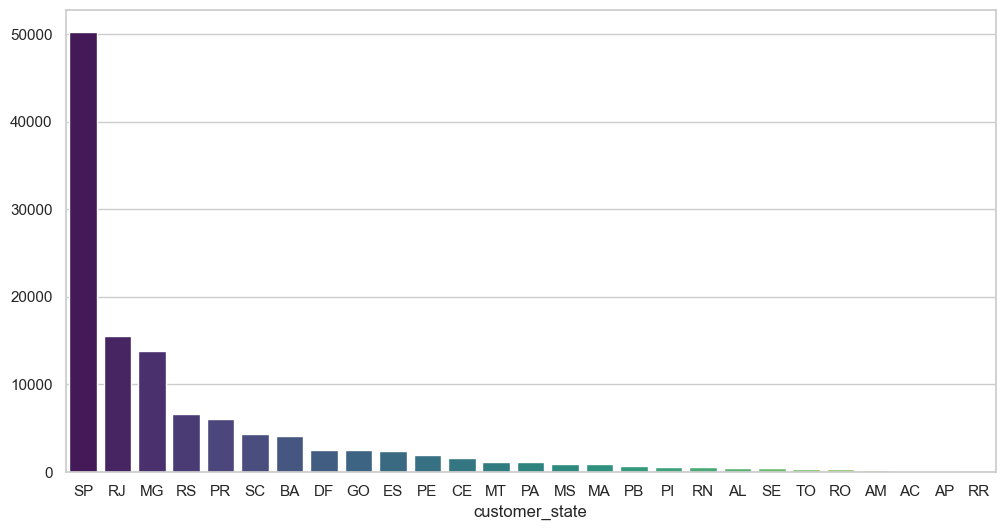

In [20]:
state_counts = df.groupby("customer_state")["order_id"].count().sort_values(ascending=False)
sns.barplot(x=state_counts.index, y=state_counts.values, palette="viridis")
plt.show()




## 4. Top 10 produits les plus vendus


/var/folders/56/l_nsck090md8fschzkqhpblh0000gn/T/ipykernel_27161/3125386721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="magma")


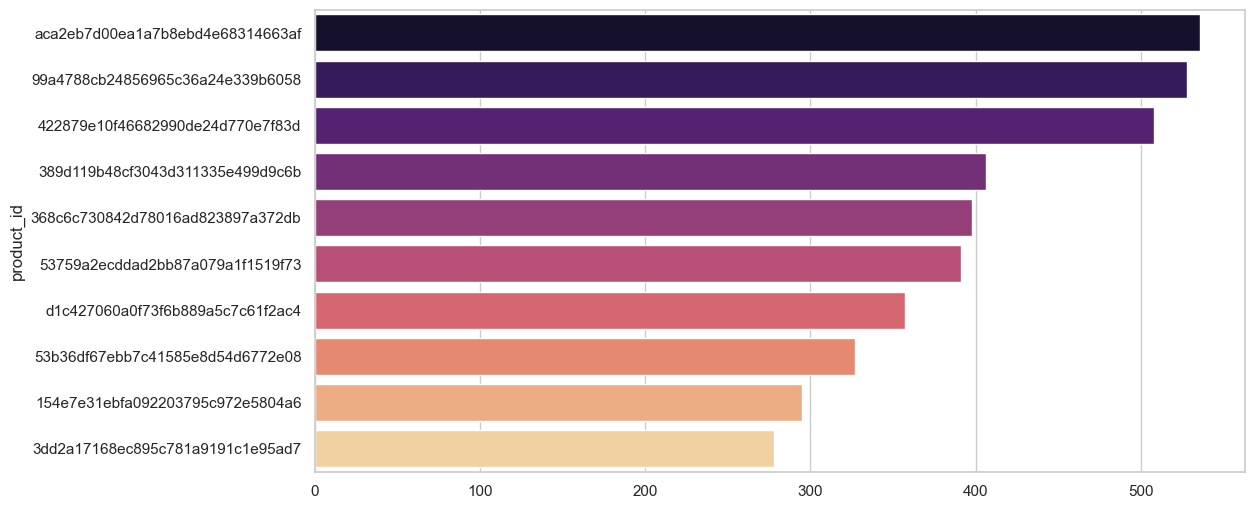

In [21]:
top_products = df.groupby("product_id")["order_id"].count().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")
plt.show()

## 5. Retard moyen de livraison

On calcule le retard moyen et on visualise sa distribution.



Retard moyen de livraison (jours) : -12.04839183560602


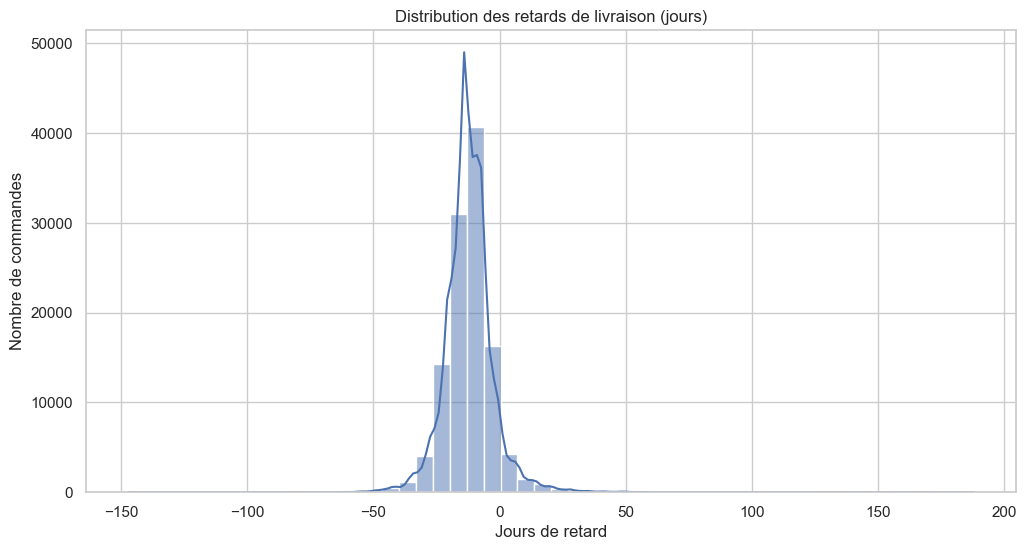

In [22]:
if 'order_delivered_customer_date' in df.columns and 'order_estimated_delivery_date' in df.columns:
    df['delivery_delay'] = (pd.to_datetime(df['order_delivered_customer_date']) - 
                            pd.to_datetime(df['order_estimated_delivery_date'])).dt.days
    print("\nRetard moyen de livraison (jours) :", df['delivery_delay'].mean())
    
    sns.histplot(df['delivery_delay'], bins=50, kde=True)
    plt.title("Distribution des retards de livraison (jours)")
    plt.xlabel("Jours de retard")
    plt.ylabel("Nombre de commandes")
    plt.show()


## 6. Conclusion

Cette analyse permet de comprendre :
- Les états avec le plus de commandes.
- Les produits les plus populaires.
- La performance des livraisons.
- Les opportunités d'amélioration pour la logistique et le stock.

Le notebook est prêt pour être présenté sur GitHub comme portfolio.


## Analyse des commandes par état et par catégorie

Dans cette section, nous examinons le nombre de commandes par **état** et par **catégorie de produit**.  
La heatmap permet d'identifier rapidement quelles régions achètent le plus certaines catégories, et ainsi détecter les zones et produits les plus populaires.


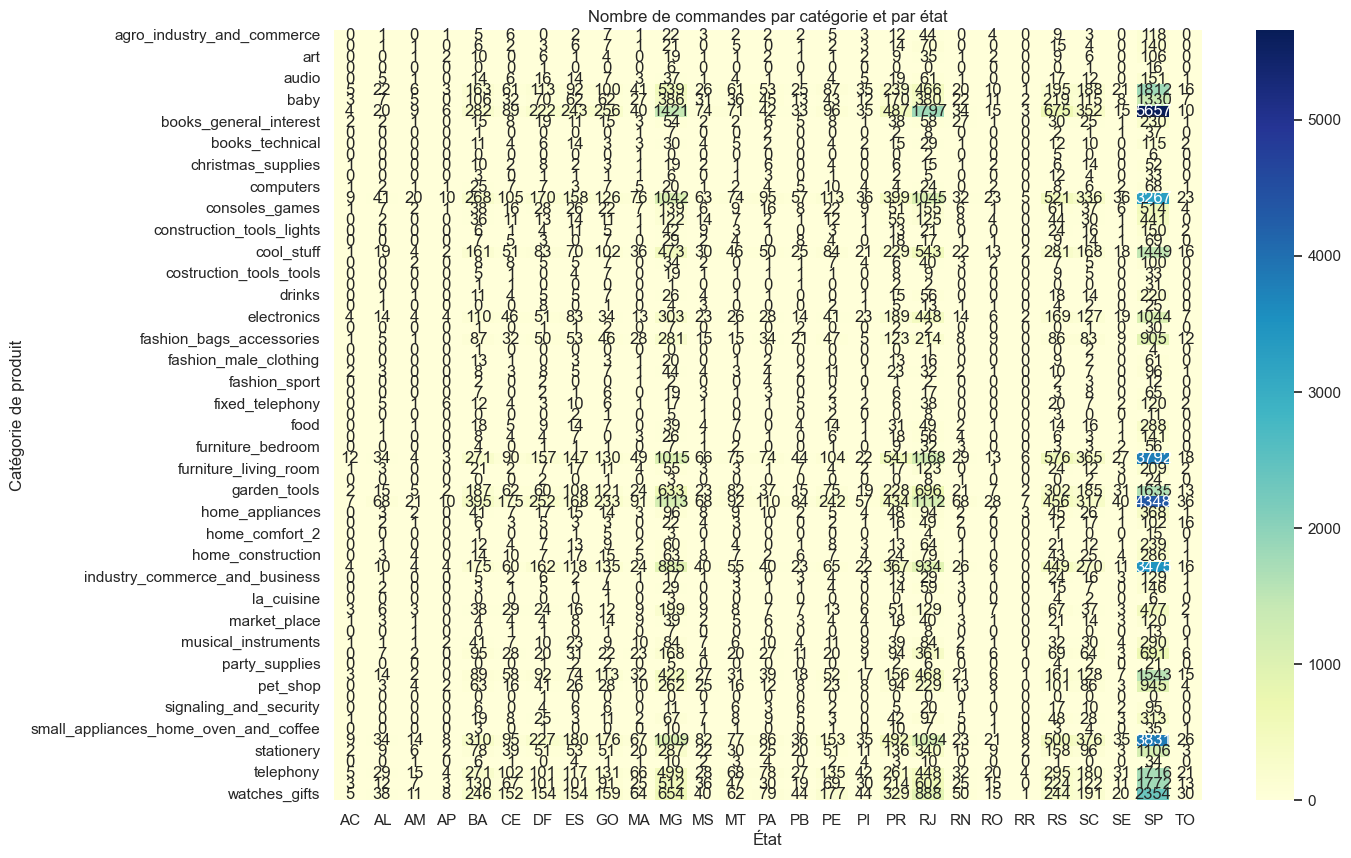

In [26]:
# Nombre de commandes par état et catégorie
state_category_counts = df.groupby(["customer_state", "product_category_name_english"])["order_id"].count().reset_index()
state_category_counts = state_category_counts.pivot(index="product_category_name_english", columns="customer_state", values="order_id").fillna(0)

# Heatmap commandes par catégorie et état
plt.figure(figsize=(14,10))
sns.heatmap(state_category_counts, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Nombre de commandes par catégorie et par état")
plt.xlabel("État")
plt.ylabel("Catégorie de produit")
plt.show()


## Évolution des commandes dans le temps

Ici, nous analysons la **série temporelle des commandes** pour détecter des tendances et la saisonnalité.  
Nous visualisons le nombre de commandes par **mois**, afin d'identifier les pics de ventes et les périodes creuses.


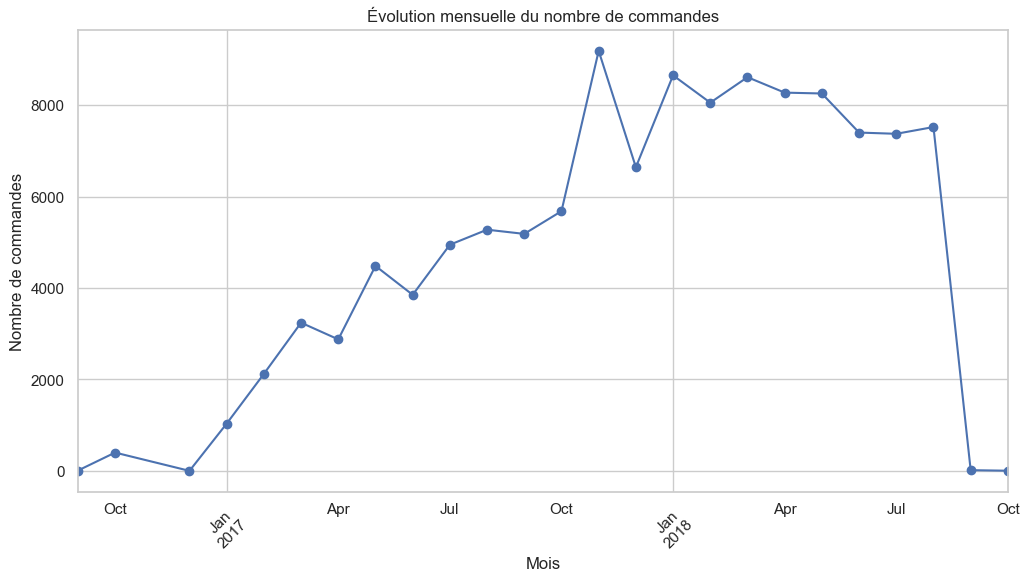

In [27]:
# Conversion de la date de commande
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Comptage mensuel
orders_per_month = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))["order_id"].count()

# Graphique évolution mensuelle
orders_per_month.plot(kind='line', marker='o')
plt.title("Évolution mensuelle du nombre de commandes")
plt.ylabel("Nombre de commandes")
plt.xlabel("Mois")
plt.xticks(rotation=45)
plt.show()


## Analyse des retards de livraison

Cette section explore la distribution des **retards de livraison** par état.  
Le boxplot permet de repérer les états avec les plus grands retards et d'identifier les outliers.


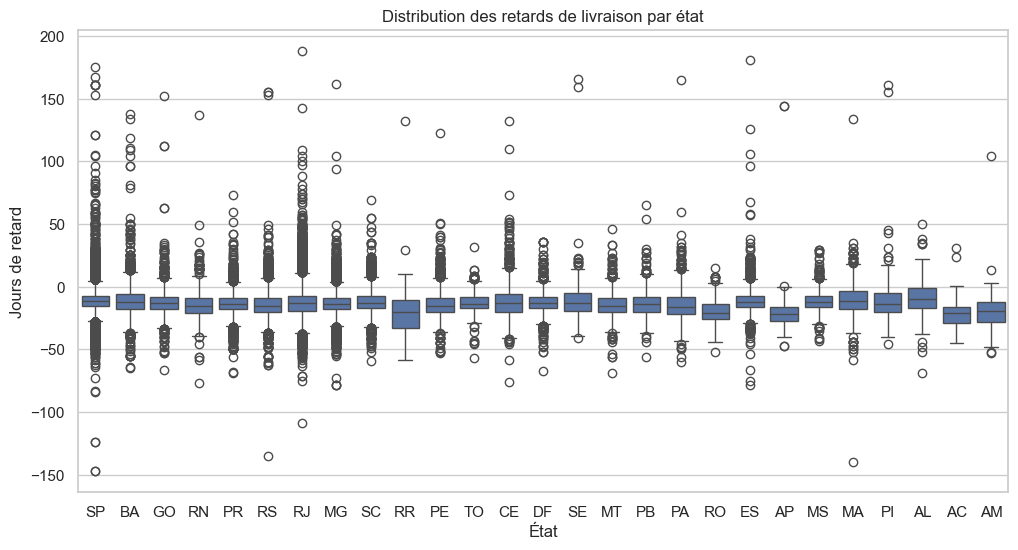

In [28]:
# Boxplot des retards par état
plt.figure(figsize=(12,6))
sns.boxplot(x="customer_state", y="delivery_delay", data=df)
plt.title("Distribution des retards de livraison par état")
plt.ylabel("Jours de retard")
plt.xlabel("État")
plt.show()


## Top clients et top vendeurs

Nous identifions ici :
- Les **10 clients les plus actifs** en nombre de commandes.
- Les **10 vendeurs ayant traité le plus de commandes**.

Ces informations sont utiles pour comprendre les clients clés et les vendeurs les plus performants.


Top 10 clients par nombre de commandes :
customer_unique_id
9a736b248f67d166d2fbb006bcb877c3    75
6fbc7cdadbb522125f4b27ae9dee4060    38
f9ae226291893fda10af7965268fb7f6    35
8af7ac63b2efbcbd88e5b11505e8098a    29
569aa12b73b5f7edeaa6f2a01603e381    26
5419a7c9b86a43d8140e2939cd2c2f7e    24
c8460e4251689ba205045f3ea17884a1    24
85963fd37bfd387aa6d915d8a1065486    24
db1af3fd6b23ac3873ef02619d548f9c    24
1d2435aa3b858d45c707c9fc25e18779    24
Name: order_id, dtype: int64


/var/folders/56/l_nsck090md8fschzkqhpblh0000gn/T/ipykernel_27161/3832181134.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette="coolwarm")


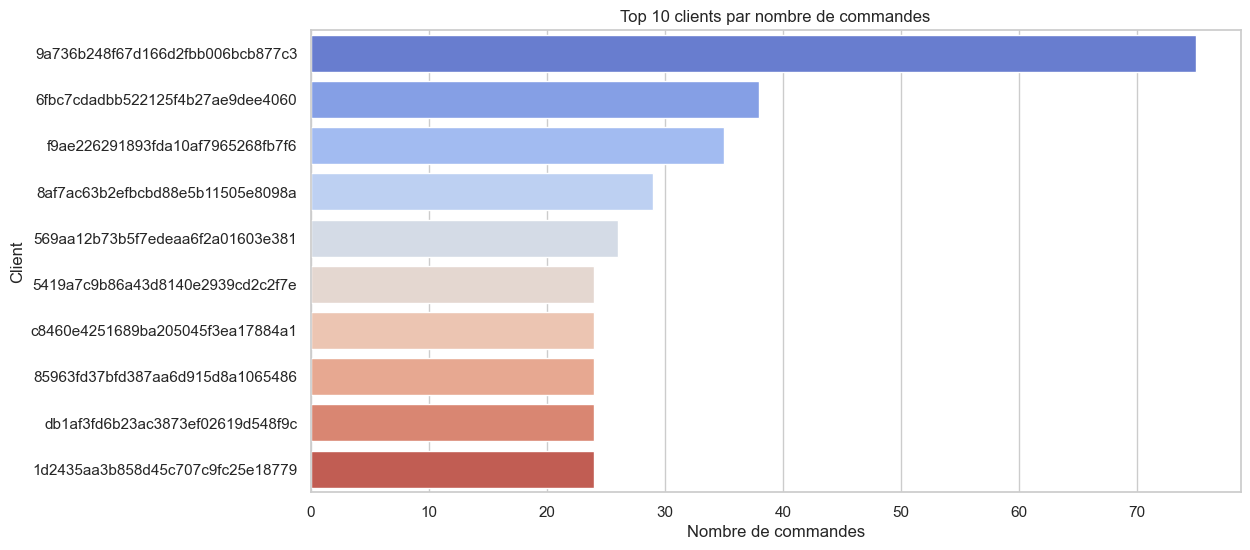


Top 10 vendeurs par nombre de commandes :
seller_id
4a3ca9315b744ce9f8e9374361493884    2155
6560211a19b47992c3666cc44a7e94c0    2130
1f50f920176fa81dab994f9023523100    2017
cc419e0650a3c5ba77189a1882b7556a    1893
da8622b14eb17ae2831f4ac5b9dab84a    1662
955fee9216a65b617aa5c0531780ce60    1530
1025f0e2d44d7041d6cf58b6550e0bfa    1477
7c67e1448b00f6e969d365cea6b010ab    1463
7a67c85e85bb2ce8582c35f2203ad736    1245
ea8482cd71df3c1969d7b9473ff13abc    1240
Name: order_id, dtype: int64


In [29]:
# Top 10 clients par nombre de commandes
top_customers = df.groupby("customer_unique_id")["order_id"].count().sort_values(ascending=False).head(10)
print("Top 10 clients par nombre de commandes :")
print(top_customers)

# Graphique top clients
sns.barplot(x=top_customers.values, y=top_customers.index, palette="coolwarm")
plt.title("Top 10 clients par nombre de commandes")
plt.xlabel("Nombre de commandes")
plt.ylabel("Client")
plt.show()

# Top 10 vendeurs par nombre de commandes
top_sellers = df.groupby("seller_id")["order_id"].count().sort_values(ascending=False).head(10)
print("\nTop 10 vendeurs par nombre de commandes :")
print(top_sellers)


# Analyse des ventes par catégorie de produit
Nous allons examiner quelles catégories de produits sont les plus vendues et visualiser leur distribution.


Top 10 catégories de produits les plus vendues :
product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: order_id, dtype: int64


/var/folders/56/l_nsck090md8fschzkqhpblh0000gn/T/ipykernel_27161/543111690.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.head(10).values, y=category_counts.head(10).index, palette="Spectral")


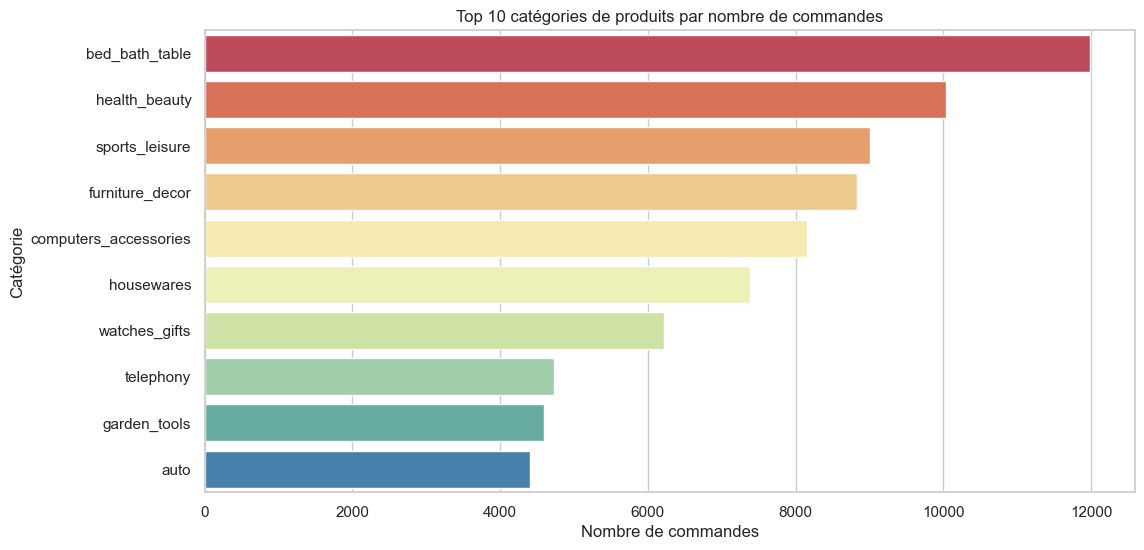

In [32]:
# Nombre de commandes par catégorie
category_counts = df.groupby("product_category_name_english")["order_id"].count().sort_values(ascending=False)

# Affichage des 10 premières catégories
print("Top 10 catégories de produits les plus vendues :")
print(category_counts.head(10))

# Graphique barres top 10 catégories
sns.barplot(x=category_counts.head(10).values, y=category_counts.head(10).index, palette="Spectral")
plt.title("Top 10 catégories de produits par nombre de commandes")
plt.xlabel("Nombre de commandes")
plt.ylabel("Catégorie")
plt.show()


# Analyse des modes de paiement
Nous allons analyser la répartition des types de paiement et leur montant moyen.


Nombre de commandes par type de paiement :
payment_type
boleto         23190
credit_card    87776
debit_card      1706
not_defined        3
voucher         6465
Name: order_id, dtype: int64


/var/folders/56/l_nsck090md8fschzkqhpblh0000gn/T/ipykernel_27161/4268661186.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.values, y=payment_counts.index, palette="coolwarm")


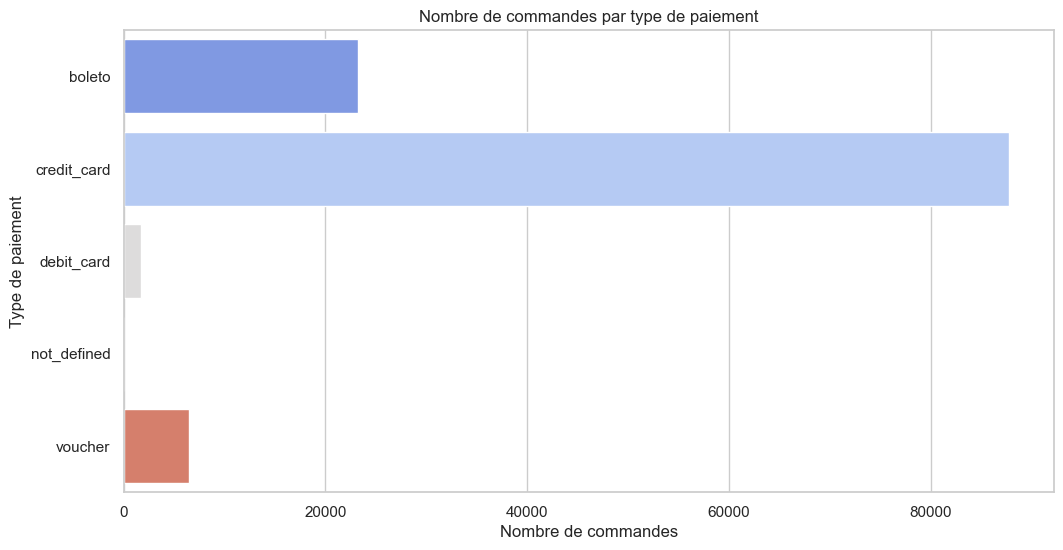


Montant moyen par type de paiement :
payment_type
credit_card    179.723963
boleto         177.271270
debit_card     150.864531
voucher         67.427353
not_defined      0.000000
Name: payment_value, dtype: float64


In [33]:
# Répartition des types de paiement
payment_counts = df.groupby("payment_type")["order_id"].count()
print("Nombre de commandes par type de paiement :")
print(payment_counts)

# Graphique
sns.barplot(x=payment_counts.values, y=payment_counts.index, palette="coolwarm")
plt.title("Nombre de commandes par type de paiement")
plt.xlabel("Nombre de commandes")
plt.ylabel("Type de paiement")
plt.show()

# Montant moyen par type de paiement
payment_mean = df.groupby("payment_type")["payment_value"].mean().sort_values(ascending=False)
print("\nMontant moyen par type de paiement :")
print(payment_mean)


# %% Section: Export du dataset final

Cette cellule permet de sauvegarder le dataset complet, après toutes les étapes de nettoyage et d'analyse, dans le dossier `data/processed`.  

Le fichier exporté pourra être utilisé pour d'autres analyses ou pour alimenter des modèles de machine learning.


In [31]:
# Création du dossier processed si nécessaire
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Export du dataset complet
df.to_csv(os.path.join(PROCESSED_DIR, "olist_full_dataset.csv"), index=False)

print("Dataset complet exporté dans :", PROCESSED_DIR)


Dataset complet exporté dans : /Users/amaury/olist-sales-forecast/data/processed
